In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv1D, MaxPooling1D, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import TimeSeriesSplit

In [2]:

# Step 1: Load Data
def load_data_india():
    dataset = pd.read_excel('All_India_CPI_2013_2024.xlsx')
    dataset = dataset.melt(id_vars='Year', var_name='Month', value_name='CPI')
    month_map = {
        'Jan': '01', 'Feb': '02', 'Mar': '03', 'Apr': '04', 'May': '05', 'Jun': '06',
        'Jul': '07', 'Aug': '08', 'Sep': '09', 'Oct': '10', 'Nov': '11', 'Dec': '12'
    }
    dataset['Month'] = dataset['Month'].map(month_map)
    dataset['Date'] = pd.to_datetime(dataset['Year'].astype(str) + '-' + dataset['Month'] + '-01') + pd.offsets.MonthEnd(1)
    dataset.sort_values(by='Date', ascending=True, inplace=True)
    dataset.drop(['Year', 'Month'], axis=1, inplace=True)
    dataset.set_index('Date', inplace=True)
    dataset.dropna(subset=['CPI'], inplace=True)
    if not dataset['CPI'].isna().any() and not dataset['CPI'].isin([float('inf'), -float('inf')]).any():
        print("Data is clean: No NaN or inf values in CPI")
    return dataset

df = load_data_india()
print(f"Data shape: {df.shape}")
print("Indian CPI Data (last 5 rows):")
print(df.tail())

FileNotFoundError: [Errno 2] No such file or directory: 'All_India_CPI_2013_2024.xlsx'

In [3]:

# Step 1: Load Data
def load_data_india():
    dataset = pd.read_excel('All_India_CPI_2013_2024.xlsx')
    dataset = dataset.melt(id_vars='Year', var_name='Month', value_name='CPI')
    month_map = {
        'Jan': '01', 'Feb': '02', 'Mar': '03', 'Apr': '04', 'May': '05', 'Jun': '06',
        'Jul': '07', 'Aug': '08', 'Sep': '09', 'Oct': '10', 'Nov': '11', 'Dec': '12'
    }
    dataset['Month'] = dataset['Month'].map(month_map)
    dataset['Date'] = pd.to_datetime(dataset['Year'].astype(str) + '-' + dataset['Month'] + '-01') + pd.offsets.MonthEnd(1)
    dataset.sort_values(by='Date', ascending=True, inplace=True)
    dataset.drop(['Year', 'Month'], axis=1, inplace=True)
    dataset.set_index('Date', inplace=True)
    dataset.dropna(subset=['CPI'], inplace=True)
    if not dataset['CPI'].isna().any() and not dataset['CPI'].isin([float('inf'), -float('inf')]).any():
        print("Data is clean: No NaN or inf values in CPI")
    return dataset

df = load_data_india()
print(f"Data shape: {df.shape}")
print("Indian CPI Data (last 5 rows):")
print(df.tail())

FileNotFoundError: [Errno 2] No such file or directory: 'All_India_CPI_2013_2024.xlsx'

In [4]:

# Step 1: Load Data
def load_data_india():
    dataset = pd.read_excel('All_India_CPI_2013_2024.xlsx')
    dataset = dataset.melt(id_vars='Year', var_name='Month', value_name='CPI')
    month_map = {
        'Jan': '01', 'Feb': '02', 'Mar': '03', 'Apr': '04', 'May': '05', 'Jun': '06',
        'Jul': '07', 'Aug': '08', 'Sep': '09', 'Oct': '10', 'Nov': '11', 'Dec': '12'
    }
    dataset['Month'] = dataset['Month'].map(month_map)
    dataset['Date'] = pd.to_datetime(dataset['Year'].astype(str) + '-' + dataset['Month'] + '-01') + pd.offsets.MonthEnd(1)
    dataset.sort_values(by='Date', ascending=True, inplace=True)
    dataset.drop(['Year', 'Month'], axis=1, inplace=True)
    dataset.set_index('Date', inplace=True)
    dataset.dropna(subset=['CPI'], inplace=True)
    if not dataset['CPI'].isna().any() and not dataset['CPI'].isin([float('inf'), -float('inf')]).any():
        print("Data is clean: No NaN or inf values in CPI")
    return dataset

df = load_data_india()
print(f"Data shape: {df.shape}")
print("Indian CPI Data (last 5 rows):")
print(df.tail())

Data is clean: No NaN or inf values in CPI
Data shape: (144, 1)
Indian CPI Data (last 5 rows):
              CPI
Date             
2024-08-31  194.2
2024-09-30  196.2
2024-10-31  196.8
2024-11-30  196.5
2024-12-31  195.4


In [5]:
# Step 2: Differencing and Normalization
series = df['CPI'].diff().dropna()  # First-order differencing for stationarity
train_size = int(0.8 * len(series))
train_data, val_data = series[:train_size], series[train_size:]
scaler = MinMaxScaler(feature_range=(0, 1))
train_data_scaled = scaler.fit_transform(train_data.values.reshape(-1, 1))
val_data_scaled = scaler.transform(val_data.values.reshape(-1, 1))  # Avoid data leakage
norm_df = np.concatenate([train_data_scaled, val_data_scaled])
joblib.dump(scaler, 'scaler_india.pkl')
print('Normalized data shape:', norm_df.shape)


Normalized data shape: (143, 1)


In [6]:
# Step 3: Sequence Creation
def create_sequences(data, n_lags):
    X, y = [], []
    for i in range(n_lags, len(data)):
        X.append(data[i - n_lags:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)


In [7]:

# Step 4: Test Different Sequence Lengths
n_lags_list = [6, 12, 24]
results = []  # Initialize results list

for n_lags in n_lags_list:
    print(f"\nTesting sequence length: {n_lags}")
    X, y = create_sequences(norm_df, n_lags)
    if len(X) == 0:
        print(f"Skipping n_lags={n_lags} due to insufficient data")
        continue
    X = np.reshape(X, (X.shape[0], X.shape[1], 1))
    y = np.reshape(y, (y.shape[0], 1))
    print('X shape:', X.shape)
    print('y shape:', y.shape)

    # Time Series Cross-Validation
    tscv = TimeSeriesSplit(n_splits=5)
    cnn_results, lstm_results, cnn_lstm_results = [], [], []

    for train_idx, val_idx in tscv.split(X):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        print(f'Train shapes: X={X_train.shape}, y={y_train.shape}')
        print(f'Validation shapes: X={X_val.shape}, y={y_val.shape}')

        # CNN Model
        cnn = Sequential([
            Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(n_lags, 1)),
            Conv1D(filters=32, kernel_size=3, activation='relu'),
            MaxPooling1D(pool_size=2),
            Dropout(0.2),
            Flatten(),
            Dense(32, activation='relu'),
            Dense(1)
        ])
        cnn.compile(optimizer='adam', loss='mean_squared_error')
        cnn_history = cnn.fit(X_train, y_train, epochs=100, batch_size=16, validation_data=(X_val, y_val),
                              callbacks=[EarlyStopping(patience=10, restore_best_weights=True),
                                         ReduceLROnPlateau(factor=0.5, patience=5)], verbose=1)

        # LSTM Model
        lstm = Sequential([
            LSTM(units=64, return_sequences=True, input_shape=(n_lags, 1)),
            Dropout(0.2),
            LSTM(units=32, return_sequences=False),
            Dropout(0.2),
            Dense(16, activation='relu'),
            Dense(1)
        ])
        lstm.compile(optimizer='adam', loss='mean_squared_error')
        lstm_history = lstm.fit(X_train, y_train, epochs=100, batch_size=16, validation_data=(X_val, y_val),
                                callbacks=[EarlyStopping(patience=10, restore_best_weights=True),
                                           ReduceLROnPlateau(factor=0.5, patience=5)], verbose=1)

        # CNN-LSTM Hybrid Model
        cnn_lstm = Sequential([
            Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(n_lags, 1)),
            MaxPooling1D(pool_size=2),
            LSTM(units=32, return_sequences=False),
            Dropout(0.2),
            Dense(16, activation='relu'),
            Dense(1)
        ])
        cnn_lstm.compile(optimizer='adam', loss='mean_squared_error')
        cnn_lstm_history = cnn_lstm.fit(X_train, y_train, epochs=100, batch_size=16, validation_data=(X_val, y_val),
                                        callbacks=[EarlyStopping(patience=10, restore_best_weights=True),
                                                   ReduceLROnPlateau(factor=0.5, patience=5)], verbose=1)

        # Evaluate
        cnn_val_pred = scaler.inverse_transform(cnn.predict(X_val, verbose=0))
        lstm_val_pred = scaler.inverse_transform(lstm.predict(X_val, verbose=0))
        cnn_lstm_val_pred = scaler.inverse_transform(cnn_lstm.predict(X_val, verbose=0))
        true_val = scaler.inverse_transform(y_val)
        cnn_results.append(mean_absolute_error(true_val, cnn_val_pred))
        lstm_results.append(mean_absolute_error(true_val, lstm_val_pred))
        cnn_lstm_results.append(mean_absolute_error(true_val, cnn_lstm_val_pred))

    print(f"Average CNN MAE (n_lags={n_lags}): {np.mean(cnn_results):.4f}")
    print(f"Average LSTM MAE (n_lags={n_lags}): {np.mean(lstm_results):.4f}")
    print(f"Average CNN-LSTM MAE (n_lags={n_lags}): {np.mean(cnn_lstm_results):.4f}")
    results.append({
        'n_lags': n_lags,
        'cnn_mae': np.mean(cnn_results),
        'lstm_mae': np.mean(lstm_results),
        'cnn_lstm_mae': np.mean(cnn_lstm_results)
    })



Testing sequence length: 6
X shape: (137, 6, 1)
y shape: (137, 1)
Train shapes: X=(27, 6, 1), y=(27, 1)
Validation shapes: X=(22, 6, 1), y=(22, 1)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 801ms/step - loss: 0.1875 - val_loss: 0.1346 - learning_rate: 0.0010
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - loss: 0.1551 - val_loss: 0.0976 - learning_rate: 0.0010
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 147ms/step - loss: 0.1133 - val_loss: 0.0666 - learning_rate: 0.0010
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - loss: 0.0784 - val_loss: 0.0445 - learning_rate: 0.0010
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - loss: 0.0570 - val_loss: 0.0337 - learning_rate: 0.0010
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - loss: 0.0565 - val_loss: 0.0338 - learning_rate: 0.0010
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - loss: 0.0544 - val_loss: 0.0375 - learning_rate: 0.0010
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - loss: 0.0780 - val_loss: 0.0385 - learning_rate: 0.0010
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step - loss: 0.0553 - val_loss: 0.0358 - learning_rate: 0.0010
Epoch 10/100
2/2 ━━

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 590ms/step - loss: 0.3318 - val_loss: 0.2342 - learning_rate: 0.0010
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 0.2817 - val_loss: 0.1996 - learning_rate: 0.0010
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.2485 - val_loss: 0.1731 - learning_rate: 0.0010
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.2101 - val_loss: 0.1465 - learning_rate: 0.0010
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 0.1657 - val_loss: 0.1199 - learning_rate: 0.0010
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.1552 - val_loss: 0.0938 - learning_rate: 0.0010
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.1065 - val_loss: 0.0696 - learning_rate: 0.0010
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0927 - val_loss: 0.0489 - learning_rate: 0.0010
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.0698 - val_loss: 0.0350 - learning_rate: 0.0010
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0

...

6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 182ms/step - loss: 0.2346 - val_loss: 0.0749 - learning_rate: 0.0010
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0724 - val_loss: 0.0628 - learning_rate: 0.0010
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0530 - val_loss: 0.0311 - learning_rate: 0.0010
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0372 - val_loss: 0.0315 - learning_rate: 0.0010
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0424 - val_loss: 0.0319 - learning_rate: 0.0010
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0451 - val_loss: 0.0344 - learning_rate: 0.0010
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0398 - val_loss: 0.0309 - learning_rate: 0.0010
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0322 - val_loss: 0.0335 - learning_rate: 0.0010
Epoch 9/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0472 - val_loss: 0.0315 - learning_rate: 0.0010
Epoch 10/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 0.2076 - val_loss: 0.1477 - learning_rate: 0.0010
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0438 - val_loss: 0.1477 - learning_rate: 0.0010
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0399 - val_loss: 0.1536 - learning_rate: 0.0010
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0383 - val_loss: 0.1413 - learning_rate: 0.0010
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0326 - val_loss: 0.1371 - learning_rate: 0.0010
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0308 - val_loss: 0.1334 - learning_rate: 0.0010
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0289 - val_loss: 0.1325 - learning_rate: 0.0010
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0364 - val_loss: 0.1275 - learning_rate: 0.0010
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0350 - val_loss: 0.1257 - learning_rate: 0.0010
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 116ms/step - loss: 0.3209 - val_loss: 0.3518 - learning_rate: 0.0010
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.1842 - val_loss: 0.1744 - learning_rate: 0.0010
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0654 - val_loss: 0.1497 - learning_rate: 0.0010
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0793 - val_loss: 0.1345 - learning_rate: 0.0010
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0391 - val_loss: 0.1429 - learning_rate: 0.0010
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0383 - val_loss: 0.1313 - learning_rate: 0.0010
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0378 - val_loss: 0.1308 - learning_rate: 0.0010
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0370 - val_loss: 0.1334 - learning_rate: 0.0010
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0445 - val_loss: 0.1319 - learning_rate: 0.0010
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0

In [8]:
# Step 5: Select Best Sequence Length
if not results:
    raise ValueError("No results generated. Check data or sequence lengths.")
best_n_lags = min(results, key=lambda x: x['cnn_lstm_mae'])['n_lags']
print(f"\nBest sequence length: {best_n_lags}")



Best sequence length: 6


In [9]:

# Step 6: Train Final Models with Best Sequence Length
X, y = create_sequences(norm_df, best_n_lags)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))
y = np.reshape(y, (y.shape[0], 1))
train_size = int(0.8 * len(X))
X_train, X_val = X[:train_size], X[train_size:]
y_train, y_val = y[:train_size], y[train_size:]
print(f'Final train shapes: X={X_train.shape}, y={y_train.shape}')
print(f'Final validation shapes: X={X_val.shape}, y={y_val.shape}')

# Final CNN
cnn = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(best_n_lags, 1)),
    Conv1D(filters=32, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),
    Flatten(),
    Dense(32, activation='relu'),
    Dense(1)
])
cnn.compile(optimizer='adam', loss='mean_squared_error')
cnn_history = cnn.fit(X_train, y_train, epochs=100, batch_size=16, validation_data=(X_val, y_val),
                      callbacks=[EarlyStopping(patience=10, restore_best_weights=True),
                                 ReduceLROnPlateau(factor=0.5, patience=5)], verbose=1)

# Final LSTM
lstm = Sequential([
    LSTM(units=64, return_sequences=True, input_shape=(best_n_lags, 1)),
    Dropout(0.2),
    LSTM(units=32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])
lstm.compile(optimizer='adam', loss='mean_squared_error')
lstm_history = lstm.fit(X_train, y_train, epochs=100, batch_size=16, validation_data=(X_val, y_val),
                        callbacks=[EarlyStopping(patience=10, restore_best_weights=True),
                                   ReduceLROnPlateau(factor=0.5, patience=5)], verbose=1)

# Final CNN-LSTM
cnn_lstm = Sequential([
    Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(best_n_lags, 1)),
    MaxPooling1D(pool_size=2),
    LSTM(units=32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])
cnn_lstm.compile(optimizer='adam', loss='mean_squared_error')
cnn_lstm_history = cnn_lstm.fit(X_train, y_train, epochs=100, batch_size=16, validation_data=(X_val, y_val),
                                callbacks=[EarlyStopping(patience=10, restore_best_weights=True),
                                           ReduceLROnPlateau(factor=0.5, patience=5)], verbose=1)


Final train shapes: X=(109, 6, 1), y=(109, 1)
Final validation shapes: X=(28, 6, 1), y=(28, 1)
Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 0.2578 - val_loss: 0.2576 - learning_rate: 0.0010
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1646 - val_loss: 0.1398 - learning_rate: 0.0010
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0616 - val_loss: 0.1281 - learning_rate: 0.0010
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0557 - val_loss: 0.1353 - learning_rate: 0.0010
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0445 - val_loss: 0.1160 - learning_rate: 0.0010
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0427 - val_loss: 0.1155 - learning_rate: 0.0010
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0480 - val_loss: 0.1144 - learning_rate: 0.0010
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0513 - val_loss: 0.1146 - learning_rate: 0.0010
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0415 - val_loss: 0.1143 - learning_rate: 0.0010
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 106ms/step - loss: 0.2461 - val_loss: 0.2789 - learning_rate: 0.0010
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.1636 - val_loss: 0.1623 - learning_rate: 0.0010
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0593 - val_loss: 0.1263 - learning_rate: 0.0010
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0600 - val_loss: 0.1209 - learning_rate: 0.0010
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0482 - val_loss: 0.1144 - learning_rate: 0.0010
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0504 - val_loss: 0.1153 - learning_rate: 0.0010
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0430 - val_loss: 0.1098 - learning_rate: 0.0010
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0462 - val_loss: 0.1098 - learning_rate: 0.0010
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0453 - val_loss: 0.1086 - learning_rate: 0.0010
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0

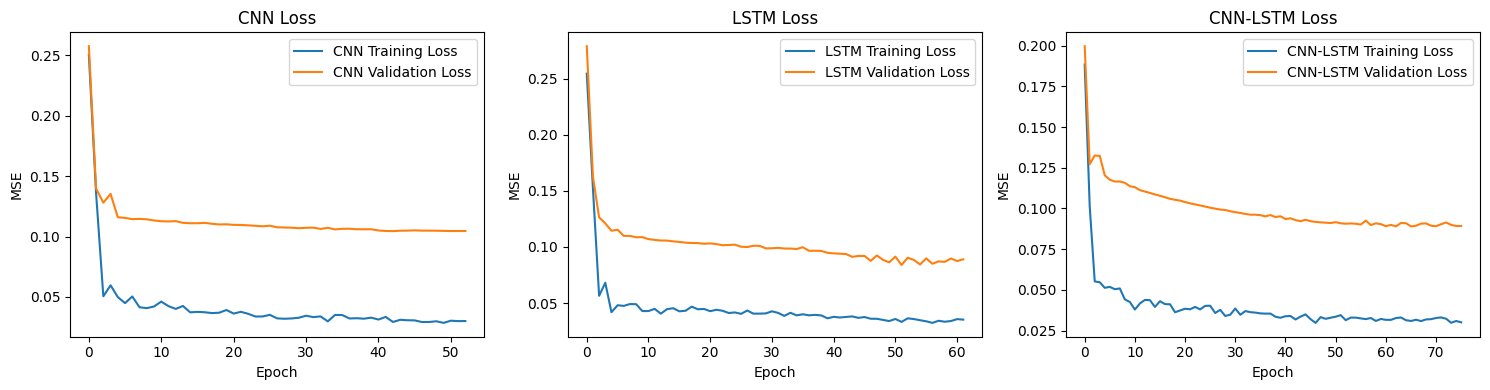

In [10]:

# Step 7: Plot Training History
plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.plot(cnn_history.history['loss'], label='CNN Training Loss')
plt.plot(cnn_history.history['val_loss'], label='CNN Validation Loss')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(lstm_history.history['loss'], label='LSTM Training Loss')
plt.plot(lstm_history.history['val_loss'], label='LSTM Validation Loss')
plt.title('LSTM Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(cnn_lstm_history.history['loss'], label='CNN-LSTM Training Loss')
plt.plot(cnn_lstm_history.history['val_loss'], label='CNN-LSTM Validation Loss')
plt.title('CNN-LSTM Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.tight_layout()
plt.show()

In [11]:

# Step 8: Evaluate Models on Validation Data
cnn_val_pred = cnn.predict(X_val, verbose=0)
lstm_val_pred = lstm.predict(X_val, verbose=0)
cnn_lstm_val_pred = cnn_lstm.predict(X_val, verbose=0)

# Inverse transform and undifference
def inverse_transform_and_undifference(predictions, scaler, last_value):
    predictions = scaler.inverse_transform(predictions)
    return np.cumsum(np.concatenate([[last_value], predictions.flatten()]))[1:]

last_value = df['CPI'].iloc[train_size + best_n_lags - 1]  # Last CPI before validation
cnn_val_pred = inverse_transform_and_undifference(cnn_val_pred, scaler, last_value)
lstm_val_pred = inverse_transform_and_undifference(lstm_val_pred, scaler, last_value)
cnn_lstm_val_pred = inverse_transform_and_undifference(cnn_lstm_val_pred, scaler, last_value)
true_val = df['CPI'].iloc[train_size + best_n_lags:].values

print('\nCNN Validation Performance:')
rmse = np.sqrt(mean_squared_error(true_val, cnn_val_pred))
r2 = r2_score(true_val, cnn_val_pred)
mae = mean_absolute_error(true_val, cnn_val_pred)
mape = mean_absolute_percentage_error(true_val, cnn_val_pred) * 100
print(f'RMSE: {rmse:.4f}')
print(f'R2: {r2:.4f}')
print(f'MAE: {mae:.4f}')
print(f'MAPE: {mape:.4f}%')

print('\nLSTM Validation Performance:')
rmse = np.sqrt(mean_squared_error(true_val, lstm_val_pred))
r2 = r2_score(true_val, lstm_val_pred)
mae = mean_absolute_error(true_val, lstm_val_pred)
mape = mean_absolute_percentage_error(true_val, lstm_val_pred) * 100
print(f'RMSE: {rmse:.4f}')
print(f'R2: {r2:.4f}')
print(f'MAE: {mae:.4f}')
print(f'MAPE: {mape:.4f}%')

print('\nCNN-LSTM Validation Performance:')
rmse = np.sqrt(mean_squared_error(true_val, cnn_lstm_val_pred))
r2 = r2_score(true_val, cnn_lstm_val_pred)
mae = mean_absolute_error(true_val, cnn_lstm_val_pred)
mape = mean_absolute_percentage_error(true_val, cnn_lstm_val_pred) * 100
print(f'RMSE: {rmse:.4f}')
print(f'R2: {r2:.4f}')
print(f'MAE: {mae:.4f}')
print(f'MAPE: {mape:.4f}%')



CNN Validation Performance:


ValueError: Found input variables with inconsistent numbers of samples: [29, 28]

In [12]:
# Step 8: Evaluate Models on Validation Data
cnn_val_pred = cnn.predict(X_val, verbose=0)
lstm_val_pred = lstm.predict(X_val, verbose=0)
cnn_lstm_val_pred = cnn_lstm.predict(X_val, verbose=0)

# Inverse transform and undifference
def inverse_transform_and_undifference(predictions, scaler, last_value):
    predictions = scaler.inverse_transform(predictions)
    return np.cumsum(np.concatenate([[last_value], predictions.flatten()]))[1:]

last_value = df['CPI'].iloc[train_size + best_n_lags - 1]  # Last CPI before validation
cnn_val_pred = inverse_transform_and_undifference(cnn_val_pred, scaler, last_value)
lstm_val_pred = inverse_transform_and_undifference(lstm_val_pred, scaler, last_value)
cnn_lstm_val_pred = inverse_transform_and_undifference(cnn_lstm_val_pred, scaler, last_value)
true_val = df['CPI'].iloc[train_size + best_n_lags:train_size + best_n_lags + len(cnn_val_pred)].values

# Debug shapes
print(f"Shape of true_val: {true_val.shape}")
print(f"Shape of cnn_val_pred: {cnn_val_pred.shape}")
print(f"Shape of lstm_val_pred: {lstm_val_pred.shape}")
print(f"Shape of cnn_lstm_val_pred: {cnn_lstm_val_pred.shape}")

print('\nCNN Validation Performance:')
rmse = np.sqrt(mean_squared_error(true_val, cnn_val_pred))
r2 = r2_score(true_val, cnn_val_pred)
mae = mean_absolute_error(true_val, cnn_val_pred)
mape = mean_absolute_percentage_error(true_val, cnn_val_pred) * 100
print(f'RMSE: {rmse:.4f}')
print(f'R2: {r2:.4f}')
print(f'MAE: {mae:.4f}')
print(f'MAPE: {mape:.4f}%')

print('\nLSTM Validation Performance:')
rmse = np.sqrt(mean_squared_error(true_val, lstm_val_pred))
r2 = r2_score(true_val, lstm_val_pred)
mae = mean_absolute_error(true_val, lstm_val_pred)
mape = mean_absolute_percentage_error(true_val, lstm_val_pred) * 100
print(f'RMSE: {rmse:.4f}')
print(f'R2: {r2:.4f}')
print(f'MAE: {mae:.4f}')
print(f'MAPE: {mape:.4f}%')

print('\nCNN-LSTM Validation Performance:')
rmse = np.sqrt(mean_squared_error(true_val, cnn_lstm_val_pred))
r2 = r2_score(true_val, cnn_lstm_val_pred)
mae = mean_absolute_error(true_val, cnn_lstm_val_pred)
mape = mean_absolute_percentage_error(true_val, cnn_lstm_val_pred) * 100
print(f'RMSE: {rmse:.4f}')
print(f'R2: {r2:.4f}')
print(f'MAE: {mae:.4f}')
print(f'MAPE: {mape:.4f}%')

Shape of true_val: (28,)
Shape of cnn_val_pred: (28,)
Shape of lstm_val_pred: (28,)
Shape of cnn_lstm_val_pred: (28,)

CNN Validation Performance:
RMSE: 2.9956
R2: 0.8076
MAE: 2.5391
MAPE: 1.3728%

LSTM Validation Performance:
RMSE: 3.1726
R2: 0.7842
MAE: 2.3926
MAPE: 1.2680%

CNN-LSTM Validation Performance:
RMSE: 2.2382
R2: 0.8926
MAE: 1.7928
MAPE: 0.9603%


In [13]:
# Step 8: Evaluate Models on Validation Data
cnn_val_pred = cnn.predict(X_val, verbose=0)
lstm_val_pred = lstm.predict(X_val, verbose=0)
cnn_lstm_val_pred = cnn_lstm.predict(X_val, verbose=0)

# Inverse transform and undifference
def inverse_transform_and_undifference(predictions, scaler, last_value):
    predictions = scaler.inverse_transform(predictions)
    return np.cumsum(np.concatenate([[last_value], predictions.flatten()]))[1:]

last_value = df['CPI'].iloc[train_size + best_n_lags - 1]  # Last CPI before validation
cnn_val_pred = inverse_transform_and_undifference(cnn_val_pred, scaler, last_value)
lstm_val_pred = inverse_transform_and_undifference(lstm_val_pred, scaler, last_value)
cnn_lstm_val_pred = inverse_transform_and_undifference(cnn_lstm_val_pred, scaler, last_value)
true_val = df['CPI'].iloc[train_size + best_n_lags:train_size + best_n_lags + len(cnn_val_pred)].values

# Debug shapes
print(f"Shape of true_val: {true_val.shape}")
print(f"Shape of cnn_val_pred: {cnn_val_pred.shape}")
print(f"Shape of lstm_val_pred: {lstm_val_pred.shape}")
print(f"Shape of cnn_lstm_val_pred: {cnn_lstm_val_pred.shape}")

print('\nCNN Validation Performance:')
rmse = np.sqrt(mean_squared_error(true_val, cnn_val_pred))
r2 = r2_score(true_val, cnn_val_pred)
mae = mean_absolute_error(true_val, cnn_val_pred)
mape = mean_absolute_percentage_error(true_val, cnn_val_pred) * 100
print(f'RMSE: {rmse:.4f}')
print(f'R2: {r2:.4f}')
print(f'MAE: {mae:.4f}')
print(f'MAPE: {mape:.4f}%')

print('\nLSTM Validation Performance:')
rmse = np.sqrt(mean_squared_error(true_val, lstm_val_pred))
r2 = r2_score(true_val, lstm_val_pred)
mae = mean_absolute_error(true_val, lstm_val_pred)
mape = mean_absolute_percentage_error(true_val, lstm_val_pred) * 100
print(f'RMSE: {rmse:.4f}')
print(f'R2: {r2:.4f}')
print(f'MAE: {mae:.4f}')
print(f'MAPE: {mape:.4f}%')

print('\nCNN-LSTM Validation Performance:')
rmse = np.sqrt(mean_squared_error(true_val, cnn_lstm_val_pred))
r2 = r2_score(true_val, cnn_lstm_val_pred)
mae = mean_absolute_error(true_val, cnn_lstm_val_pred)
mape = mean_absolute_percentage_error(true_val, cnn_lstm_val_pred) * 100
print(f'RMSE: {rmse:.4f}')
print(f'R2: {r2:.4f}')
print(f'MAE: {mae:.4f}')
print(f'MAPE: {mape:.4f}%')

Shape of true_val: (28,)
Shape of cnn_val_pred: (28,)
Shape of lstm_val_pred: (28,)
Shape of cnn_lstm_val_pred: (28,)

CNN Validation Performance:
RMSE: 2.9956
R2: 0.8076
MAE: 2.5391
MAPE: 1.3728%

LSTM Validation Performance:
RMSE: 3.1726
R2: 0.7842
MAE: 2.3926
MAPE: 1.2680%

CNN-LSTM Validation Performance:
RMSE: 2.2382
R2: 0.8926
MAE: 1.7928
MAPE: 0.9603%


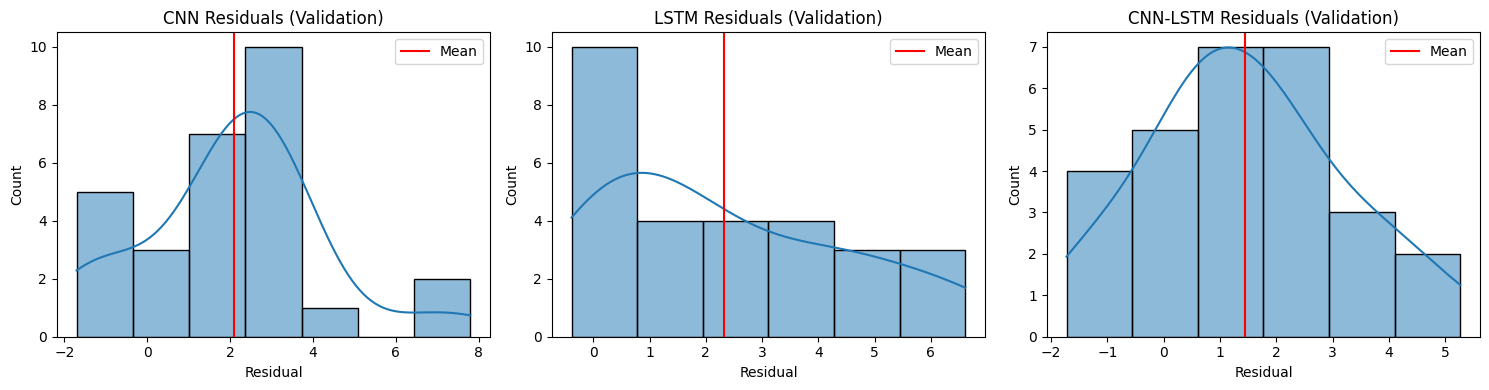

In [14]:

# Step 9: Residual Analysis
cnn_val_resid = true_val - cnn_val_pred
lstm_val_resid = true_val - lstm_val_pred
cnn_lstm_val_resid = true_val - cnn_lstm_val_pred

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
sns.histplot(x=cnn_val_resid, kde=True)
plt.axvline(x=cnn_val_resid.mean(), color='red', label='Mean')
plt.title('CNN Residuals (Validation)')
plt.xlabel('Residual')
plt.ylabel('Count')
plt.legend()

plt.subplot(1, 3, 2)
sns.histplot(x=lstm_val_resid, kde=True)
plt.axvline(x=lstm_val_resid.mean(), color='red', label='Mean')
plt.title('LSTM Residuals (Validation)')
plt.xlabel('Residual')
plt.ylabel('Count')
plt.legend()

plt.subplot(1, 3, 3)
sns.histplot(x=cnn_lstm_val_resid, kde=True)
plt.axvline(x=cnn_lstm_val_resid.mean(), color='red', label='Mean')
plt.title('CNN-LSTM Residuals (Validation)')
plt.xlabel('Residual')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

In [15]:

# Step 10: Forecast January-February 2025
forecast_period = 2
cnn_forecast, lstm_forecast, cnn_lstm_forecast = [], [], []
last_sequence = norm_df[-best_n_lags:, 0]
last_value = df['CPI'].iloc[-1]  # Last observed CPI for undifferencing

# CNN Forecast
current_sequence = last_sequence.copy()
for _ in range(forecast_period):
    current_sequence_reshaped = np.reshape(current_sequence, (1, best_n_lags, 1))
    next_pred = cnn.predict(current_sequence_reshaped, verbose=0)
    cnn_forecast.append(next_pred[0, 0])
    current_sequence = np.append(current_sequence[1:], next_pred[0, 0])

cnn_forecast = inverse_transform_and_undifference(np.array(cnn_forecast).reshape(-1, 1), scaler, last_value)

# LSTM Forecast
current_sequence = last_sequence.copy()
for _ in range(forecast_period):
    current_sequence_reshaped = np.reshape(current_sequence, (1, best_n_lags, 1))
    next_pred = lstm.predict(current_sequence_reshaped, verbose=0)
    lstm_forecast.append(next_pred[0, 0])
    current_sequence = np.append(current_sequence[1:], next_pred[0, 0])

lstm_forecast = inverse_transform_and_undifference(np.array(lstm_forecast).reshape(-1, 1), scaler, last_value)

# CNN-LSTM Forecast
current_sequence = last_sequence.copy()
for _ in range(forecast_period):
    current_sequence_reshaped = np.reshape(current_sequence, (1, best_n_lags, 1))
    next_pred = cnn_lstm.predict(current_sequence_reshaped, verbose=0)
    cnn_lstm_forecast.append(next_pred[0, 0])
    current_sequence = np.append(current_sequence[1:], next_pred[0, 0])

cnn_lstm_forecast = inverse_transform_and_undifference(np.array(cnn_lstm_forecast).reshape(-1, 1), scaler, last_value)

# Forecast DataFrame
forecast_dates = pd.date_range(start='2025-01-31', periods=2, freq='M')
df_forecasts = pd.DataFrame({
    'date': forecast_dates,
    'cnn': cnn_forecast,
    'lstm': lstm_forecast,
    'cnn_lstm': cnn_lstm_forecast
})
df_forecasts.set_index('date', inplace=True)
print("\nPredicted CPI for January-February 2025:")
print(df_forecasts)



Predicted CPI for January-February 2025:
                   cnn        lstm    cnn_lstm
date                                          
2025-01-31  195.359503  195.516202  195.445666
2025-02-28  195.588246  195.963385  195.653001


/tmp/ipython-input-15-940741812.py:38: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  forecast_dates = pd.date_range(start='2025-01-31', periods=2, freq='M')


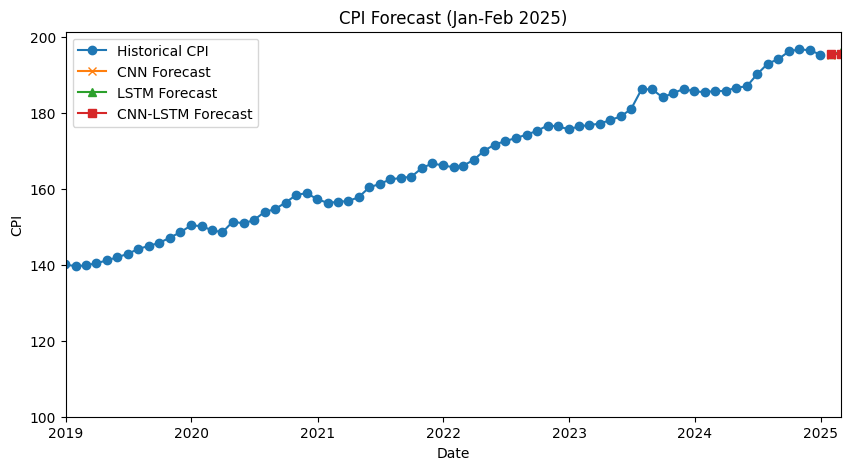

In [16]:

# Step 11: Plot Forecasts
plt.figure(figsize=(10, 5))
plt.plot(df['CPI'], label='Historical CPI', marker='o')
plt.plot(df_forecasts.index, df_forecasts['cnn'], label='CNN Forecast', marker='x')
plt.plot(df_forecasts.index, df_forecasts['lstm'], label='LSTM Forecast', marker='^')
plt.plot(df_forecasts.index, df_forecasts['cnn_lstm'], label='CNN-LSTM Forecast', marker='s')
plt.title('CPI Forecast (Jan-Feb 2025)')
plt.xlabel('Date')
plt.ylabel('CPI')
plt.xlim(pd.Timestamp('2019-01-01'), df_forecasts.index[-1])
plt.legend()
plt.show()

# Step 12: Save Models and Results
cnn.save('cnn_model_india.h5')
lstm.save('lstm_model_india.h5')
cnn_lstm.save('cnn_lstm_model_india.h5')
df_forecasts.to_csv('combined_forecast_india.csv')